In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch as pt

import biotite
import biotite.structure as struc
import biotite.structure.io as strucio

import runtime as rt

from tqdm import tqdm
from glob import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

### Benchmark

In [2]:
benchmark_df = pd.read_csv('datasets/gRNAde_benchmark.csv')

In [3]:
# create a new column for RISoTTo recovery rate
risotto_recovery = []
for pdb_id in benchmark_df['pdb_id'].to_list():
    info, seq = rt.read_fasta(f'predictions/{pdb_id}.fasta')
    risotto_recovery.append(float(info.split('|')[1].split('=')[1]))
benchmark_df['RISoTTo_recovery'] = risotto_recovery
benchmark_df

,pdb_id,description,vienna_recovery,farna_recovery,rosetta_recovery,rdesign_recovery,grnade_recovery,grnade_perplexity,grnade_sc_score,RISoTTo_recovery
0,1CSL,RRE high affinity site,0.256629,0.20,0.44,0.4455,0.472107,1.318132,0.569252,0.4643
1,1ET4,Vitamin B12 binding RNA aptamer,0.258523,0.34,0.44,0.3929,0.625000,1.345786,-0.013572,0.3943
2,1F27,Biotin-binding RNA pseudoknot,0.295139,0.36,0.37,0.3013,0.441071,1.493890,0.043075,0.2333
3,1L2X,Viral RNA pseudoknot,0.244835,0.45,0.48,0.3727,0.584375,1.433715,0.137968,0.7037
4,1LNT,RNA internal loop of SRP,0.325000,0.27,0.53,0.5556,0.571970,1.281257,0.864459,0.7273
5,1Q9A,Sarcin/ricin domain from E.coli 23S rRNA,0.274554,0.40,0.41,0.4417,0.951923,1.091351,0.776850,0.9259
6,4FE5,Guanine riboswitch aptamer,0.291667,0.28,0.36,0.4112,0.500000,1.390537,0.663003,0.4776
7,1X9C,All-RNA hairpin ribozyme,0.262019,0.31,0.50,0.3967,0.650000,1.236339,-0.025190,0.7667
8,1XPE,HIV-1 B RNA dimerization initiation site,0.270965,0.24,0.40,0.3834,0.530093,1.382483,0.911600,0.5435
9,2GCS,Pre-cleavage state of glmS ribozyme,0.248884,0.26,0.44,0.4518,0.507812,1.305386,0.406233,0.5775


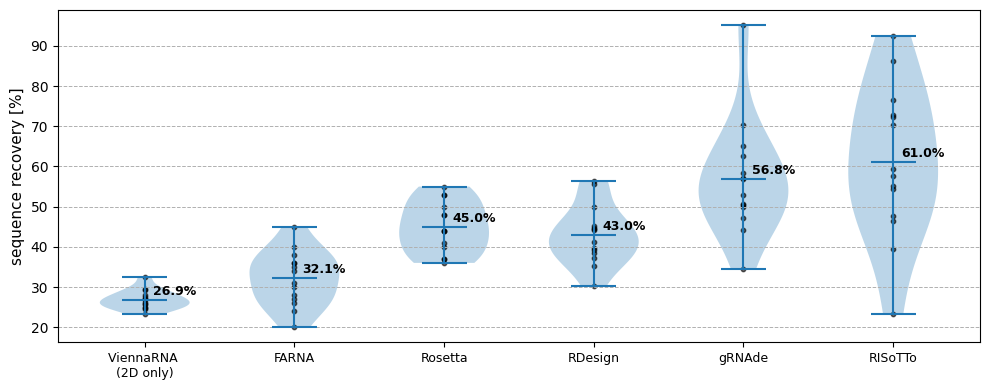

In [4]:
# Original and display column names
original_column_names = ['vienna_recovery', 'farna_recovery', 'rosetta_recovery', 'rdesign_recovery', 'grnade_recovery', 'RISoTTo_recovery']
new_column_names = ['ViennaRNA \n(2D only)', 'FARNA', 'Rosetta', 'RDesign','gRNAde', 'RISoTTo']

# Multiply by 100 to convert recovery to percentage
benchmark_df_percent = benchmark_df[original_column_names] * 100

plt.figure(figsize=(10, 4))
plt.violinplot(
    [benchmark_df_percent[col].dropna() for col in original_column_names],
    positions=np.arange(1, len(original_column_names) + 1),
    showmeans=True,
    widths=0.6
)

# Add scatter points and mean annotations
for i, col in enumerate(original_column_names):
    y_values = benchmark_df_percent[col].dropna()
    x_pos = i + 1

    jittered_x = np.random.normal(loc=x_pos, scale=0.0, size=len(y_values))
    plt.scatter(jittered_x, y_values, alpha=0.6, s=10, color='black')

    mean_val = np.mean(y_values)
    plt.text(x_pos + 0.20, mean_val + 0.5, f'{mean_val:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='black')

plt.xticks(np.arange(1, len(new_column_names) + 1), new_column_names, fontsize=9)
plt.ylabel('sequence recovery [%]', fontsize=11)

ax = plt.gca()

plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()

plt.savefig('predictions/benchmark_ts14.png', dpi=300, bbox_inches='tight')
plt.savefig('predictions/benchmark_ts14.svg', dpi=300, bbox_inches='tight')
plt.savefig('predictions/benchmark_ts14.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [5]:
benchmark_df_full = pd.read_csv('datasets/grnade_full_benchmark.csv')
benchmark_df_full

,pdb_id,grnade_recovery
0,3DVZ,0.961538
1,1Q9A,0.956731
2,480D,0.884615
3,483D,0.860577
4,1MSY,0.855769
...,...,...
166,3G4M,0.424242
167,3RKF,0.420942
168,2NPZ,0.407328
169,4MEH,0.389142


In [6]:
risotto_scores = []
risotto_recovery = []

for pdb_id in benchmark_df_full['pdb_id']:
    pred_fasta_file = f'predictions/{pdb_id}.fasta'
    pdb_path = f'/media/bibekar/e500c9b8-094e-4f88-983c-27f30285d37a/bibekar/kuma_backup/carbonara-rna/data/data/all_bioassemblies/pdbs/{pdb_id}.pdb'

    if os.path.exists(pred_fasta_file) and os.path.exists(pdb_path):
        try:
            # Get recovery
            info, seq = rt.read_fasta(pred_fasta_file)
            recovery = float(info.split('|')[1].split('=')[1])
            risotto_recovery.append(recovery)

            # Get self-consistency
            pred_ss = rt.predict_secondary_structure(pred_fasta_file)
            # pred_ss = rt.predict_secondary_structure_ribonanzanet(pred_fasta_file, device='cuda')
            structure = strucio.load_structure(pdb_path)
            nucleotides = structure[struc.filter_nucleotides(structure)]
            real_ss = struc.dot_bracket_from_structure(nucleotides)[0]
            real_ss = "".join([c if c in ['.', '(', ')'] else '.' for c in real_ss])
            trimmed_real_ss = real_ss[:len(pred_ss)]

            score = rt.self_consistency_secondary(pred_ss, trimmed_real_ss)#, keep_pseudoknots=False)
            # print(f"{pdb_id} → Recovery: {recovery}, Self-consistency: {score}")

            risotto_scores.append(score)
        except Exception as e:
            print(f"Error processing {pdb_id}: {e}")
            risotto_scores.append(None)
            risotto_recovery.append(None)
    else:
        print(f"Missing file(s) for {pdb_id}")
        risotto_scores.append(None)
        risotto_recovery.append(None)

# Add both columns to the dataframe
benchmark_df_full["RISoTTo_sc_score"] = risotto_scores
benchmark_df_full["RISoTTo_recovery"] = risotto_recovery

/home/bibekar/miniconda3/envs/pesto/lib/python3.11/site-packages/biotite/structure/hbond.py:268: UserWarning: Input structure has no associated 'BondList', Hydrogen atoms bonded to donors are detected by distance
  warnings.warn(
/home/bibekar/miniconda3/envs/pesto/lib/python3.11/site-packages/biotite/structure/basepairs.py:1175: IncompleteStructureWarning: Nucleotide with res_id 24 and chain_id A has less than 3 base atoms, unable to check for base pair.
  warnings.warn(
/home/bibekar/miniconda3/envs/pesto/lib/python3.11/site-packages/biotite/structure/basepairs.py:1175: IncompleteStructureWarning: Nucleotide with res_id 33 and chain_id A has less than 3 base atoms, unable to check for base pair.
  warnings.warn(
/home/bibekar/miniconda3/envs/pesto/lib/python3.11/site-packages/biotite/structure/basepairs.py:1175: IncompleteStructureWarning: Nucleotide with res_id 44 and chain_id A has less than 3 base atoms, unable to check for base pair.
  warnings.warn(
/home/bibekar/miniconda3/envs

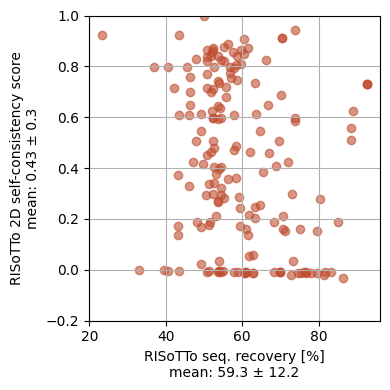

In [7]:
mean_recovery_rate = np.mean(risotto_recovery)*100
std_recovery_rate = np.std(risotto_recovery)*100
mean_sc_score = np.mean(risotto_scores)
std_sc_score = np.std(risotto_scores)
plt.figure(figsize=(4, 4))
plt.scatter(benchmark_df_full['RISoTTo_recovery']*100, benchmark_df_full['RISoTTo_sc_score'], color='#bf4e30', alpha=0.6)
plt.ylim(-0.2, 1)
# plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='y=x')
# plt.title('RISoTTo seq. recovery vs RISoTTo 2D self-consistency score')
plt.xlabel(f'RISoTTo seq. recovery [%]\nmean: {mean_recovery_rate:.1f} ± {std_recovery_rate:.1f}')
plt.ylabel(f'RISoTTo 2D self-consistency score\nmean: {mean_sc_score:.2f} ± {std_sc_score:.1f}')
plt.grid()
# plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('predictions/test_recovey_sc2D.png', dpi=300, bbox_inches='tight')
plt.savefig('predictions/test_recovey_sc2D.svg', dpi=300, bbox_inches='tight')
plt.savefig('predictions/test_recovey_sc2D.pdf', dpi=300, bbox_inches='tight')
plt.show()

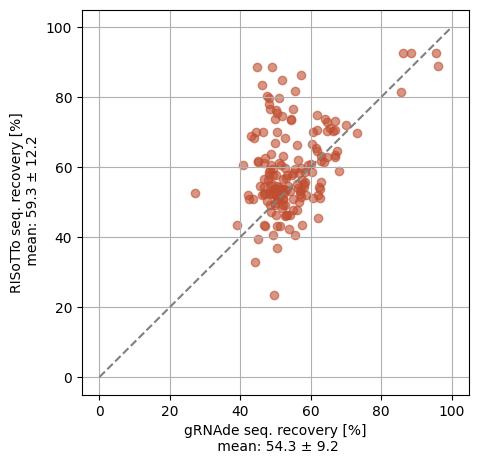

In [8]:
grnade_recovery_mean = benchmark_df_full['grnade_recovery'].mean()*100
grnade_recovery_std = benchmark_df_full['grnade_recovery'].std()*100
RISoTTo_recovery_mean = benchmark_df_full['RISoTTo_recovery'].mean()*100
RISoTTo_recovery_std = benchmark_df_full['RISoTTo_recovery'].std()*100
# sctter plot of grnade_recovery vs RISoTTo_recovery
plt.figure(figsize=(5, 5))
plt.scatter(benchmark_df_full['grnade_recovery']*100, benchmark_df_full['RISoTTo_recovery']*100, color='#bf4e30', alpha=0.6)
plt.plot([0, 100], [0, 100], color='grey', linestyle='--', label='y=x')
plt.xlabel('gRNAde seq. recovery [%]\n mean: {:.1f} ± {:.1f}'.format(grnade_recovery_mean, grnade_recovery_std))
plt.ylabel('RISoTTo seq. recovery [%]\n mean: {:.1f} ± {:.1f}'.format(RISoTTo_recovery_mean, RISoTTo_recovery_std))
plt.grid()
plt.savefig('predictions/test_grnade_vs_RISoTTo_recovery.png', dpi=300, bbox_inches='tight')
plt.savefig('predictions/test_grnade_vs_RISoTTo_recovery.svg', dpi=300, bbox_inches='tight')
plt.savefig('predictions/test_grnade_vs_RISoTTo_recovery.pdf', dpi=300, bbox_inches='tight')
plt.show()